# PAI — Análise Automatizada de Retina (OCT + Retinopatia Diabética)

> **Pontifícia Universidade Católica do Rio de Janeiro (PUC-Rio)**
> MBA em Generative AI & Large Language Models — Turma 2026.1
> Disciplina: **PAI — Processamento e Análise de Imagens**
> Professora: Manoela
> Aluno: **Rafael Tardelli Pacheco dos Santos** — tardelli.rafael@gmail.com

Pipeline de **inferência** (sem re-treino) que recebe uma ou duas imagens de retina —
um B-scan de **OCT** e/ou uma **retinografia colorida** — roteia cada modalidade para o
seu modelo RETFound já treinado, calcula indicadores de confiança e consolida tudo em um
JSON estruturado, validado por schema, pronto para consumo por uma LLM de laudo.

## 1. Descrição do problema

**Contexto clínico.** Três das principais causas de perda visual evitável têm achados
detectáveis por imagem de retina: a **degeneração macular relacionada à idade (DMRI)**, o
**edema macular diabético (EMD)** e a **retinopatia diabética (RD)**. O rastreio precoce
muda o prognóstico — em RD proliferativa e EMD, o tratamento oportuno previne cegueira —
mas esbarra na escassez de especialistas frente ao volume de exames.

**Relevância epidemiológica.** A RD é a principal causa de cegueira em adultos em idade
produtiva; a prevalência de diabetes cresce e, com ela, a demanda por triagem. A DMRI é a
principal causa de perda visual central em idosos. Ferramentas de apoio que priorizam
casos e sinalizam achados aumentam a cobertura do rastreio.

**Duas modalidades complementares.** As duas patologias se enxergam melhor em imagens
diferentes: a **OCT** (corte transversal, revela camadas e fluido — CNV, EMD, drusas),
e a **retinografia colorida** (vista de superfície — microaneurismas, hemorragias,
neovasos que graduam a RD). Por isso o sistema aceita as duas e roteia cada uma ao modelo
adequado.

**O que o sistema decide / não decide.** Decide, para cada imagem: a classe mais provável
segundo o modelo, com probabilidades e um nível de confiança; e gera recomendações
determinísticas de triagem. **Não** emite diagnóstico, não localiza/mede lesões, não cobre
achados fora das classes treinadas e não dispensa a leitura por oftalmologista.

## 2. Base de dados

Os pesos usados aqui foram **fine-tuned** por terceiros (organização `bitfount`) sobre dois
datasets públicos. Não treinamos nada; descrevemos as bases de origem para contextualizar
vieses e limites de generalização.

### Modelo A — OCT · dataset Kermany / OCT2017
- **~84 mil** B-scans de OCT espectral (SD-OCT Heidelberg Spectralis), 4 classes:
  **CNV, DME, DRUSEN, NORMAL**; conjunto de teste oficial com **1.000** imagens (250/classe).
- **Aquisição:** cortes maculares 2D de múltiplos centros; imagens já recortadas na região
  de interesse.
- **Vieses conhecidos:** fornecedor único de OCT, forte desbalanceamento de classes no
  treino, seleção de imagens de boa qualidade (menos artefatos do que a rotina), população
  não representativa de todas as etnias.

### Modelo B — Fundo · dataset IDRiD (Indian Diabetic Retinopathy Image Dataset)
- **516** retinografias coloridas (**413** treino / **103** teste), graduadas na escala
  **ICDR 0–4** (mais rótulos de risco de EMD, não usados aqui).
- **Aquisição:** câmera Kowa VX-10α, campo de 50°, centrada na mácula, 4288×2848 px,
  população indiana.
- **Vieses conhecidos:** base pequena, desbalanceada (poucos graus intermediários), um único
  equipamento/centro e uma única população — generalização limitada para outras câmeras.

## 3. Metodologia

**Arquitetura RETFound.** Ambos os modelos são **ViT-Large/16** inicializados a partir do
RETFound, um *foundation model* de retina pré-treinado com **Masked Autoencoder (MAE)** sobre
**~1,6 milhão** de imagens retinianas não rotuladas. Esse pré-treino auto-supervisionado
aprende representações genéricas da retina, que são então especializadas por *fine-tuning*
supervisionado em cada tarefa (OCT2017 para o modelo A; IDRiD para o modelo B).

**Pré-processamento.** Conversão para RGB, redimensionamento para 224×224 com *center crop*
(crop_pct 0.9, interpolação bicúbica) e normalização com as estatísticas ImageNet do
pré-treino RETFound. O **modelo B foi treinado com imagens em tons de cinza**, então a
retinografia é convertida para *greyscale* antes da normalização (a guarda de modalidade,
porém, roda sobre a imagem colorida original).

**Roteamento por modalidade + guarda.** Um mapa `modalidade → modelo` direciona cada imagem.
Antes de inferir, uma heurística de baixo custo (saturação HSV média) confirma a modalidade
declarada; em caso de divergência, o modelo incompatível **não** é executado.

**Critério de confiança.** Para cada predição calculamos `p_max`, `margin` (top-1 − top-2) e
`entropy_norm` (entropia de Shannon normalizada), classificados em faixas explícitas de
confiança (alta/média/baixa) que alimentam recomendações determinísticas.

## 4. Setup, dependências e configuração

Toda a configuração (checkpoints, device, limiares) vem de **variáveis de ambiente** (`.env`),
com *defaults* seguros. Nada de caminhos ou hiperparâmetros *hard-coded*. Instalação, kernel e
como obter os pesos estão no `README.md` — o notebook começa direto pela configuração.

In [1]:
from __future__ import annotations

import io
import json
import math
import os
import time
import uuid
import hashlib
import datetime as dt
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Literal, Optional

import numpy as np
from PIL import Image, ImageOps
import torch
import timm
from timm.data import resolve_data_config, create_transform
import jsonschema
from dotenv import load_dotenv

Modality = Literal["OCT", "FUNDUS"]


def set_seed(seed: int) -> None:
    """Fixa as seeds de numpy/torch para tornar a inferência reprodutível."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@dataclass(frozen=True)
class Thresholds:
    """Limiares de confiança (seção 3 / enunciado 6). Ajustáveis via .env."""
    pmax_high: float
    margin_high: float
    pmax_low: float
    entropy_high: float


@dataclass(frozen=True)
class Config:
    """Configuração imutável do pipeline, lida do ambiente."""
    model_oct_checkpoint: str
    model_fundus_checkpoint: str
    data_dir: Path
    output_dir: Path
    device_preference: str
    seed: int
    thresholds: Thresholds
    modality_saturation_threshold: float


def load_config() -> Config:
    """Lê a configuração de variáveis de ambiente (.env), com defaults seguros."""
    load_dotenv()

    def _f(name: str, default: float) -> float:
        return float(os.getenv(name, str(default)))

    cfg = Config(
        model_oct_checkpoint=os.getenv("MODEL_OCT_CHECKPOINT", "bitfount/RETFound_MAE_OCT_CNV_DME_DRU"),
        model_fundus_checkpoint=os.getenv("MODEL_FUNDUS_CHECKPOINT", "bitfount/RETFound_DR_IDRID"),
        data_dir=Path(os.getenv("DATA_DIR", "./data")),
        output_dir=Path(os.getenv("OUTPUT_DIR", "./outputs")),
        device_preference=os.getenv("DEVICE_PREFERENCE", "auto"),
        seed=int(os.getenv("SEED", "42")),
        thresholds=Thresholds(
            pmax_high=_f("CONF_PMAX_HIGH", 0.85),
            margin_high=_f("CONF_MARGIN_HIGH", 0.30),
            pmax_low=_f("CONF_PMAX_LOW", 0.60),
            entropy_high=_f("CONF_ENTROPY_HIGH", 0.75),
        ),
        modality_saturation_threshold=_f("MODALITY_SATURATION_THRESHOLD", 0.12),
    )
    cfg.data_dir.mkdir(parents=True, exist_ok=True)
    cfg.output_dir.mkdir(parents=True, exist_ok=True)
    return cfg


CONFIG = load_config()
set_seed(CONFIG.seed)
CONFIG

/home/rafael/projects/oct-image-analyzer/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Config(model_oct_checkpoint='bitfount/RETFound_MAE_OCT_CNV_DME_DRU', model_fundus_checkpoint='bitfount/RETFound_DR_IDRID', data_dir=PosixPath('data'), output_dir=PosixPath('outputs'), device_preference='auto', seed=42, thresholds=Thresholds(pmax_high=0.85, margin_high=0.3, pmax_low=0.6, entropy_high=0.75), modality_saturation_threshold=0.12)

## 5. Carregamento dos modelos

### O que cada modelo verifica e retorna (resumo clínico)

**Modelo A — RETFound OCT (`RETFound_MAE_OCT_CNV_DME_DRU`).** Lê um **B-scan de OCT macular**
(corte transversal das camadas da retina) e devolve a probabilidade de **4 classes**:

| Classe | O que significa clinicamente |
|--------|------------------------------|
| **CNV** | *Neovascularização de coroide* — vasos anômalos sob a retina com fluido/sangue sub-retiniano; marca a **DMRI exsudativa (úmida)**. |
| **DME** | *Edema macular diabético* — espessamento da mácula por fluido intrarretiniano; complicação da retinopatia diabética. |
| **DRUSEN** | Depósitos amarelados sub-retinianos; marcador de **DMRI seca** inicial/intermediária. |
| **NORMAL** | Sem sinais patológicos nas camadas analisadas. |

Retorna apenas a **categoria mais provável do corte** (com probabilidades); não localiza a
lesão, não mede espessura e não cobre outros achados (membrana epirretiniana, fluido isolado…).

**Modelo B — RETFound Fundo/RD (`RETFound_DR_IDRID`).** Lê uma **retinografia colorida** e
**grada a retinopatia diabética** na escala **ICDR (0–4)**:

| Grau | Rótulo | Achados típicos |
|------|--------|-----------------|
| 0 | No DR | Sem retinopatia |
| 1 | Mild DR | Microaneurismas isolados |
| 2 | Moderate DR | Hemorragias, exsudatos, mais microaneurismas |
| 3 | Severe DR | Regra 4-2-1 (hemorragias em 4 quadrantes, veias em rosário em 2, IRMA em 1) |
| 4 | Progressed DR | Neovascularização (RD proliferativa); risco de hemovítreo/descolamento |

Retorna a probabilidade por grau; **grau ≥ 3** dispara sinal de encaminhamento prioritário.
O checkpoint foi treinado em imagens convertidas para **tons de cinza**, então a inferência
aplica essa conversão antes de normalizar.

Os rótulos são definidos manualmente a partir dos *model cards* (os checkpoints `timm` não
expõem `id2label`); a origem é registrada no JSON como `labels_source: "manual"`.

In [2]:
# Rótulos lidos dos model cards (os checkpoints timm não expõem id2label).
# Registrados no JSON como labels_source = "manual".
LABEL_REGISTRY: dict[str, dict[str, Any]] = {
    "OCT": {
        "labels": ["CNV", "DME", "DRUSEN", "NORMAL"],
        "source": "manual",
        "source_note": (
            "Ordem inferida da convenção alfabética do ImageFolder no Kermany/OCT2017 "
            "(CNV, DME, DRUSEN, NORMAL); não documentada explicitamente pelo autor do "
            "checkpoint. Validar com imagens de classe conhecida antes de uso clínico."
        ),
    },
    "FUNDUS": {
        "labels": ["No DR", "Mild DR", "Moderate DR", "Severe DR", "Progressed DR"],
        "source": "manual",
        "source_note": "Ordem explícita no model card (0=No DR ... 4=Progressed DR, escala ICDR).",
    },
}


def get_device(preference: str = "auto") -> torch.device:
    """Detecta o dispositivo. 'auto' => CUDA -> MPS -> CPU."""
    preference = preference.lower()
    if preference == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA solicitado, mas torch.cuda.is_available() é False.")
        return torch.device("cuda")
    if preference == "cpu":
        return torch.device("cpu")
    mps = getattr(torch.backends, "mps", None)
    if preference == "mps":
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if mps is not None and mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass
class LoadedModel:
    """Um checkpoint RETFound carregado, com transform e metadados de rótulo."""
    key: Modality
    name: str
    checkpoint: str
    task: str
    modality_expected: Modality
    labels: list[str]
    labels_source: str
    to_grayscale: bool
    model: torch.nn.Module
    transform: Callable[[Image.Image], torch.Tensor]


def load_model(
    checkpoint: str,
    modality_expected: Modality,
    task: str,
    to_grayscale: bool,
    device: torch.device,
) -> LoadedModel:
    """Carrega um checkpoint via timm (hf_hub) e resolve o transform de pré-processamento."""
    try:
        model = timm.create_model(f"hf_hub:{checkpoint}", pretrained=True)
    except Exception as exc:  # falha explícita de carregamento (rede, id inválido, etc.)
        raise RuntimeError(f"Falha ao carregar checkpoint '{checkpoint}': {exc}") from exc
    model.to(device).eval()
    data_config = resolve_data_config({}, model=model)
    transform = create_transform(**data_config)
    reg = LABEL_REGISTRY[modality_expected]
    if model.num_classes != len(reg["labels"]):
        raise ValueError(
            f"num_classes ({model.num_classes}) != nº de rótulos ({len(reg['labels'])}) "
            f"para {checkpoint}."
        )
    return LoadedModel(
        key=modality_expected,
        name=Path(checkpoint).name,
        checkpoint=checkpoint,
        task=task,
        modality_expected=modality_expected,
        labels=reg["labels"],
        labels_source=reg["source"],
        to_grayscale=to_grayscale,
        model=model,
        transform=transform,
    )


DEVICE = get_device(CONFIG.device_preference)

MODEL_OCT = load_model(
    CONFIG.model_oct_checkpoint, "OCT",
    task="Classificacao de patologia macular (CNV/DME/Drusen/Normal)",
    to_grayscale=False, device=DEVICE,
)
MODEL_FUNDUS = load_model(
    CONFIG.model_fundus_checkpoint, "FUNDUS",
    task="Graduacao de retinopatia diabetica (ICDR 0-4)",
    to_grayscale=True, device=DEVICE,
)
LOADED_MODELS: list[LoadedModel] = [MODEL_OCT, MODEL_FUNDUS]

print(f"Device: {DEVICE}")
for lm in LOADED_MODELS:
    print(f"- {lm.name}: {lm.model.num_classes} classes {lm.labels} | grayscale={lm.to_grayscale}")

Device: cpu
- RETFound_MAE_OCT_CNV_DME_DRU: 4 classes ['CNV', 'DME', 'DRUSEN', 'NORMAL'] | grayscale=False
- RETFound_DR_IDRID: 5 classes ['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Progressed DR'] | grayscale=True


## 6. Entrada de imagens e detecção de modalidade

**Modo interativo:** dois `FileUpload` rotulados — o *slot* define a modalidade, eliminando a
classe de erro mais provável do projeto. **Modo lote** (opcional): arquivos em `data/` com
prefixo `oct_*` / `fundus_*`. Ambos produzem a mesma estrutura interna (`ExamInput`).

**Guarda de modalidade:** a saturação HSV média distingue OCT (quase acromático) de
retinografia (fortemente saturada). Se a modalidade estimada divergir da declarada, o modelo
incompatível é marcado `skipped_modality_mismatch` e **não** roda.

Se nenhum *upload* for feito e `data/` estiver vazio, o notebook cai para a imagem de exemplo
`oct_exemplo.jpg` (declarada como OCT) — assim executa de ponta a ponta em runtime limpo.

In [3]:
@dataclass
class ExamInput:
    """Uma imagem de exame já validada e convertida para RGB."""
    input_id: str
    filename: str
    modality_declared: Modality
    image_rgb: Image.Image
    sha256: str
    original_size: tuple[int, int]


def build_exam_input(input_id: str, filename: str, modality: Modality, data: bytes) -> ExamInput:
    """Constrói um ExamInput a partir dos bytes do arquivo, validando integridade."""
    try:
        image = Image.open(io.BytesIO(data))
        image.load()
    except Exception as exc:
        raise ValueError(f"Arquivo de imagem invalido ({filename}): {exc}") from exc
    rgb = image.convert("RGB")
    return ExamInput(
        input_id=input_id,
        filename=filename,
        modality_declared=modality,
        image_rgb=rgb,
        sha256=hashlib.sha256(data).hexdigest(),
        original_size=(rgb.width, rgb.height),
    )


def estimate_modality(image_rgb: Image.Image, threshold: float) -> tuple[str, float, float]:
    """Heurística de modalidade de baixo custo.

    OCT (B-scan) é quase acromático (baixa saturação, pouca variação entre canais RGB);
    retinografia é fortemente saturada. Retorna (estimada, saturacao_media, std_entre_canais).
    """
    arr = np.asarray(image_rgb).astype(np.float32) / 255.0
    sat_mean = float(np.asarray(image_rgb.convert("HSV"))[..., 1].astype(np.float32).mean() / 255.0)
    channel_std = float(arr.std(axis=2).mean())
    estimated = "OCT" if sat_mean <= threshold else "FUNDUS"
    return estimated, sat_mean, channel_std


_IMG_EXT = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}


def parse_batch_inputs(data_dir: Path) -> list[ExamInput]:
    """Modo lote: lê imagens de data/ pela convenção de nome oct_* / fundus_*."""
    inputs: list[ExamInput] = []
    for path in sorted(data_dir.glob("*")):
        if path.suffix.lower() not in _IMG_EXT:
            continue
        name = path.name.lower()
        if name.startswith("oct_"):
            modality: Modality = "OCT"
        elif name.startswith("fundus_"):
            modality = "FUNDUS"
        else:
            continue
        inputs.append(build_exam_input(f"{modality.lower()}_{len(inputs) + 1}", path.name, modality, path.read_bytes()))
    return inputs


import ipywidgets as widgets
from IPython.display import display

oct_uploader = widgets.FileUpload(accept="image/*", multiple=False)
fundus_uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(widgets.VBox([
    widgets.HTML("<b>Imagem de OCT (B-scan)</b>"), oct_uploader,
    widgets.HTML("<b>Retinografia colorida (fundo de olho)</b>"), fundus_uploader,
]))

In [4]:
def _from_uploader(uploader: "widgets.FileUpload", modality: Modality) -> Optional[ExamInput]:
    """Extrai um ExamInput de um FileUpload (ipywidgets 8), se houver arquivo."""
    values = uploader.value
    if not values:
        return None
    item = values[0]
    return build_exam_input(f"{modality.lower()}_1", item["name"], modality, bytes(item["content"]))


def resolve_inputs() -> list[ExamInput]:
    """Coleta 1–2 imagens: prioriza uploads; senão lote em data/; senão exemplo empacotado."""
    collected: list[ExamInput] = []
    for uploader, modality in [(oct_uploader, "OCT"), (fundus_uploader, "FUNDUS")]:
        item = _from_uploader(uploader, modality)
        if item is not None:
            collected.append(item)
    if collected:
        return collected
    batch = parse_batch_inputs(CONFIG.data_dir)
    if batch:
        return batch[:2]
    example = Path("./oct_exemplo.jpg")
    if example.exists():
        return [build_exam_input("oct_1", example.name, "OCT", example.read_bytes())]
    raise RuntimeError("Nenhuma imagem fornecida (uploads, data/ ou oct_exemplo.jpg).")


EXAM_INPUTS = resolve_inputs()

print(f"{len(EXAM_INPUTS)} imagem(ns) coletada(s):")
for ei in EXAM_INPUTS:
    est, sat, cstd = estimate_modality(ei.image_rgb, CONFIG.modality_saturation_threshold)
    ok = "OK" if est == ei.modality_declared else "DIVERGE"
    print(f"- {ei.input_id} ({ei.filename}) declarada={ei.modality_declared} "
          f"estimada={est} [{ok}] | saturacao={sat:.4f}")

1 imagem(ns) coletada(s):


- oct_1 (oct_exemplo.jpg) declarada=OCT estimada=OCT [OK] | saturacao=0.0108


## 7. Pré-processamento

Cada imagem é analisada quanto à qualidade (contraste, nitidez) e transformada conforme o
modelo de destino: RGB → *greyscale* (apenas modelo B) → resize 224 + *center crop* →
normalização ImageNet. As etapas aplicadas são registradas em `preprocessing` no JSON.

In [5]:
def image_quality_flags(image_rgb: Image.Image) -> list[str]:
    """Flags simples de qualidade: low_contrast (desvio baixo), blur (pouca nitidez).

    Limiares indicativos, calibráveis; servem de sinal de triagem, não de rejeição dura.
    """
    gray = np.asarray(ImageOps.grayscale(image_rgb)).astype(np.float32)
    gy, gx = np.gradient(gray)
    sharpness = float(np.var(np.sqrt(gx ** 2 + gy ** 2)))
    flags: list[str] = []
    if float(gray.std()) < 40.0:
        flags.append("low_contrast")
    if sharpness < 100.0:
        flags.append("blur")
    return flags


def preprocess_for_model(image_rgb: Image.Image, loaded: LoadedModel) -> tuple[torch.Tensor, list[str]]:
    """Aplica o transform do modelo (com greyscale para o modelo B) e lista as etapas."""
    steps = ["to_rgb"]
    img = image_rgb
    if loaded.to_grayscale:
        img = ImageOps.grayscale(img).convert("RGB")
        steps.append("to_grayscale")
    tensor = loaded.transform(img).unsqueeze(0)
    steps += ["resize_224", "center_crop", "normalize_imagenet"]
    return tensor, steps


@dataclass
class InputAnalysis:
    """Resultado da análise de uma entrada: modalidade estimada, flags e pré-processamento."""
    exam: ExamInput
    modality_estimated: str
    saturation_mean: float
    channel_std: float
    modality_agreement: bool
    quality_flags: list[str]
    preprocessing: list[str]


def analyze_input(exam: ExamInput, models_by_modality: dict[str, LoadedModel]) -> InputAnalysis:
    """Detecta modalidade, levanta flags de qualidade e resolve o pré-processamento aplicável."""
    est, sat, cstd = estimate_modality(exam.image_rgb, CONFIG.modality_saturation_threshold)
    agreement = est == exam.modality_declared
    flags = image_quality_flags(exam.image_rgb)
    if not agreement:
        flags = flags + ["modality_mismatch_warning"]
    _, steps = preprocess_for_model(exam.image_rgb, models_by_modality[exam.modality_declared])
    return InputAnalysis(exam, est, sat, cstd, agreement, flags, steps)


def input_to_json(a: InputAnalysis) -> dict[str, Any]:
    """Serializa uma InputAnalysis no objeto 'input' do envelope (schema 1.0)."""
    return {
        "input_id": a.exam.input_id,
        "filename": a.exam.filename,
        "sha256": a.exam.sha256,
        "original_size": [int(a.exam.original_size[0]), int(a.exam.original_size[1])],
        "modality_declared": a.exam.modality_declared,
        "modality_estimated": a.modality_estimated,
        "modality_agreement": a.modality_agreement,
        "saturation_mean": round(a.saturation_mean, 6),
        "preprocessing": a.preprocessing,
        "quality_flags": a.quality_flags,
    }

## 8. Inferência e roteamento

Cada modelo recebe apenas a entrada de sua modalidade. A inferência roda sob
`torch.no_grad()`, com seed fixa, no dispositivo detectado, medindo a latência. O status de
cada modelo é explícito: `ok`, `no_input`, `skipped_modality_mismatch` ou `error`. Campos de
predição só existem quando `status == "ok"` — nunca zeros ou distribuição uniforme.

In [6]:
def confidence_indicators(probs: np.ndarray, thr: Thresholds) -> dict[str, Any]:
    """Calcula p_max, margin (top1-top2) e entropia normalizada; classifica a confiança."""
    probs = np.asarray(probs, dtype=np.float64)
    order = np.argsort(probs)[::-1]
    p_max = float(probs[order[0]])
    p_second = float(probs[order[1]]) if probs.size > 1 else 0.0
    margin = p_max - p_second
    n = int(probs.size)
    ent = float(-np.sum(np.where(probs > 0, probs * np.log(probs), 0.0)))
    entropy_norm = ent / math.log(n) if n > 1 else 0.0
    if p_max >= thr.pmax_high and margin >= thr.margin_high:
        level = "alta"
    elif p_max < thr.pmax_low or entropy_norm > thr.entropy_high:
        level = "baixa"
    else:
        level = "média"
    return {
        "p_max": round(p_max, 6),
        "margin": round(float(margin), 6),
        "entropy_norm": round(entropy_norm, 6),
        "level": level,
    }


def run_inference(loaded: LoadedModel, exam: ExamInput, device: torch.device) -> tuple[np.ndarray, float]:
    """Roda um modelo em uma imagem sob no_grad e retorna (probabilidades, latencia_ms)."""
    tensor, _ = preprocess_for_model(exam.image_rgb, loaded)
    tensor = tensor.to(device)
    start = time.perf_counter()
    with torch.no_grad():
        logits = loaded.model(tensor)
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    probs = torch.softmax(logits.float().cpu()[0], dim=-1).numpy()
    return probs, elapsed_ms


def build_model_entry(
    loaded: LoadedModel,
    analyses_by_modality: dict[str, InputAnalysis],
    device: torch.device,
    thr: Thresholds,
) -> dict[str, Any]:
    """Monta o objeto 'model' do envelope, com status e predição (só quando ok)."""
    entry: dict[str, Any] = {
        "name": loaded.name,
        "checkpoint": loaded.checkpoint,
        "task": loaded.task,
        "modality_expected": loaded.modality_expected,
        "input_id": None,
        "status": "no_input",
        "labels_source": loaded.labels_source,
        "labels": None,
        "probabilities": None,
        "top1": None,
        "confidence": None,
        "inference_time_ms": None,
        "error": None,
    }
    analysis = analyses_by_modality.get(loaded.modality_expected)
    if analysis is None:
        return entry  # nenhuma imagem para esta modalidade
    entry["input_id"] = analysis.exam.input_id
    if not analysis.modality_agreement:
        entry["status"] = "skipped_modality_mismatch"
        return entry
    try:
        probs, ms = run_inference(loaded, analysis.exam, device)
        top_idx = int(np.argmax(probs))
        entry.update({
            "status": "ok",
            "labels": loaded.labels,
            "probabilities": {lbl: round(float(p), 6) for lbl, p in zip(loaded.labels, probs)},
            "top1": {"label": loaded.labels[top_idx], "probability": round(float(probs[top_idx]), 6)},
            "confidence": confidence_indicators(probs, thr),
            "inference_time_ms": round(ms, 3),
        })
    except Exception as exc:  # falha isolada não derruba o pipeline
        entry["status"] = "error"
        entry["error"] = str(exc)
    return entry

## 9. Pós-processamento, confiança e recomendações

As recomendações são **regras determinísticas** (não texto de LLM) derivadas das faixas de
confiança, das flags de qualidade e do grau ICDR: confiança baixa → repetir/segunda opinião;
achado patológico com confiança média → acompanhamento mais próximo; grau ICDR ≥ 3 →
encaminhamento prioritário; uma só modalidade → avaliação parcial.

In [7]:
def build_recommendations(inputs_json: list[dict], models_json: list[dict]) -> list[str]:
    """Gera recomendações determinísticas a partir de flags, confiança e grau ICDR."""
    recs: list[str] = []
    evaluated = {m["modality_expected"] for m in models_json if m["status"] != "no_input"}
    if len(evaluated) < 2:
        recs.append("Apenas uma modalidade avaliada; avaliação parcial do exame.")

    for inp in inputs_json:
        if "modality_mismatch_warning" in inp["quality_flags"]:
            recs.append(f"Entrada {inp['input_id']}: modalidade declarada e estimada divergem; "
                        "modelo correspondente não executado.")
        if {"low_contrast", "blur"} & set(inp["quality_flags"]):
            recs.append(f"Entrada {inp['input_id']}: qualidade de imagem baixa; considerar repetir a captura.")

    for m in models_json:
        if m["status"] != "ok":
            continue
        conf, top = m["confidence"], m["top1"]
        if conf["level"] == "baixa":
            recs.append(f"{m['name']}: confiança baixa (p_max={conf['p_max']:.2f}); "
                        "sugerir repetição do exame ou segunda opinião.")
        if m["modality_expected"] == "FUNDUS":
            if m["labels"].index(top["label"]) >= 3:
                recs.append(f"{m['name']}: grau ICDR elevado ({top['label']}); sinalizar encaminhamento prioritário.")
        if m["modality_expected"] == "OCT" and top["label"] != "NORMAL" and conf["level"] == "média":
            recs.append(f"{m['name']}: achado patológico ({top['label']}) com confiança média; "
                        "sugerir acompanhamento em intervalo menor.")

    if not recs:
        recs.append("Sem alertas automáticos; manter conduta de rotina conforme avaliação médica.")
    return recs

## 10. Geração e validação do JSON

O envelope é montado, **validado contra `schema.json`** (`jsonschema`) e salvo em `outputs/`.
Além do schema, verifica-se que as probabilidades de cada modelo `ok` somam ≈ 1.

In [8]:
DISCLAIMER = (
    "Ferramenta de apoio à decisão para uso acadêmico. Não substitui avaliação médica nem "
    "constitui diagnóstico. Modelos com acurácia limitada, treinados em datasets específicos; "
    "toda saída exige revisão por oftalmologista."
)


def build_evaluation(
    exam_inputs: list[ExamInput],
    loaded_models: list[LoadedModel],
    device: torch.device,
    cfg: Config,
) -> dict[str, Any]:
    """Executa o pipeline completo e monta o envelope de saída (schema 1.0)."""
    models_by_modality = {m.modality_expected: m for m in loaded_models}
    analyses = [analyze_input(ei, models_by_modality) for ei in exam_inputs]
    analyses_by_modality = {a.exam.modality_declared: a for a in analyses}
    inputs_json = [input_to_json(a) for a in analyses]
    models_json = [build_model_entry(m, analyses_by_modality, device, cfg.thresholds) for m in loaded_models]
    return {
        "exam_id": str(uuid.uuid4()),
        "timestamp_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "schema_version": "1.0",
        "inputs": inputs_json,
        "models": models_json,
        "recommendations": build_recommendations(inputs_json, models_json),
        "disclaimer": DISCLAIMER,
    }


def validate_evaluation(evaluation: dict[str, Any], schema_path: Path = Path("./schema.json")) -> None:
    """Valida o envelope contra o schema e confere a soma das probabilidades (~1)."""
    with open(schema_path, encoding="utf-8") as fh:
        schema = json.load(fh)
    jsonschema.validate(instance=evaluation, schema=schema)
    for m in evaluation["models"]:
        if m["status"] == "ok":
            total = sum(m["probabilities"].values())
            if abs(total - 1.0) > 1e-3:
                raise AssertionError(f"Probabilidades de {m['name']} somam {total:.6f} (esperado ~1).")


EVALUATION = build_evaluation(EXAM_INPUTS, LOADED_MODELS, DEVICE, CONFIG)
validate_evaluation(EVALUATION)

out_path = CONFIG.output_dir / f"evaluation_{EVALUATION['exam_id'][:8]}.json"
with open(out_path, "w", encoding="utf-8") as fh:
    json.dump(EVALUATION, fh, ensure_ascii=False, indent=2)

print(f"JSON válido (schema 1.0) salvo em: {out_path}\n")
print(json.dumps(EVALUATION, ensure_ascii=False, indent=2))

JSON válido (schema 1.0) salvo em: outputs/evaluation_f267a9eb.json

{
  "exam_id": "f267a9eb-482b-4608-b8e7-b4184d5e630d",
  "timestamp_utc": "2026-08-26T22:56:32.332027+00:00",
  "schema_version": "1.0",
  "inputs": [
    {
      "input_id": "oct_1",
      "filename": "oct_exemplo.jpg",
      "sha256": "400a618f4281d34e99eccdcb1f7b1c997fb42cbec9ff97239144c5288eb19735",
      "original_size": [
        2371,
        1288
      ],
      "modality_declared": "OCT",
      "modality_estimated": "OCT",
      "modality_agreement": true,
      "saturation_mean": 0.010815,
      "preprocessing": [
        "to_rgb",
        "resize_224",
        "center_crop",
        "normalize_imagenet"
      ],
      "quality_flags": [
        "blur"
      ]
    }
  ],
  "models": [
    {
      "name": "RETFound_MAE_OCT_CNV_DME_DRU",
      "checkpoint": "bitfount/RETFound_MAE_OCT_CNV_DME_DRU",
      "task": "Classificacao de patologia macular (CNV/DME/Drusen/Normal)",
      "modality_expected": "OCT",
     

## 11. Interface de laudo (stub)

Assinatura da função que uma LLM usará para gerar o laudo. **Não implementada** nesta etapa —
o template será fornecido depois. A LLM deverá receber apenas campos interpretáveis
(`inputs`, `models.labels/probabilities/top1/confidence`, `recommendations`), nunca embeddings.

In [9]:
def gerar_laudo(json_saida: dict, layout: str) -> str:
    """Gera um laudo textual a partir do JSON de avaliação validado.

    NÃO implementado nesta etapa: o template de laudo será fornecido depois. A LLM de laudo
    deve consumir apenas campos clinicamente interpretáveis do envelope (inputs, models com
    labels/probabilities/top1/confidence e recommendations) — nunca representações internas.

    Args:
        json_saida: envelope validado contra schema.json (schema_version "1.0").
        layout: identificador do template de laudo a aplicar.

    Returns:
        O laudo estruturado em texto.

    Raises:
        NotImplementedError: sempre, enquanto o template de laudo não for definido.
    """
    raise NotImplementedError("Geração de laudo será implementada quando o template for fornecido.")

## 12. Relato dos experimentos

Como o uso previsto é a avaliação de **1–2 imagens por exame** (não um lote rotulado), os
experimentos abaixo são de **auto-consistência**: caracterizam o comportamento do pipeline
sobre as imagens realmente carregadas. Métricas que exigem *ground truth* de muitas imagens
(matriz de confusão, precisão/recall/F1, AUC) ficam habilitadas pelo mesmo código quando se
populam imagens rotuladas em `data/` (convenção `oct_*`/`fundus_*`), mas não são calculadas
aqui por não haver rótulos de referência neste cenário de uso.

Cada experimento traz **hipótese**, **procedimento** e imprime o **resultado numérico**; a
interpretação segue a seção 13.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


def probs_for(loaded: LoadedModel, image_rgb: Image.Image) -> np.ndarray:
    """Probabilidades do modelo para uma imagem PIL (respeita o greyscale do modelo B)."""
    probs, _ = run_inference(loaded, ExamInput("_", "_", loaded.modality_expected, image_rgb,
                                               "", (image_rgb.width, image_rgb.height)), DEVICE)
    return probs


def model_for_input(exam: ExamInput) -> LoadedModel:
    """Modelo correspondente à modalidade declarada da entrada."""
    return {m.modality_expected: m for m in LOADED_MODELS}[exam.modality_declared]


# Considera nos experimentos apenas entradas cuja modalidade declarada confere (roteáveis).
ROUTABLE = [ei for ei in EXAM_INPUTS
            if estimate_modality(ei.image_rgb, CONFIG.modality_saturation_threshold)[0] == ei.modality_declared]
print(f"Entradas roteáveis para experimentos: {[ei.input_id for ei in ROUTABLE]}")

Entradas roteáveis para experimentos: ['oct_1']


### Experimento 1 — Guarda de modalidade (saturação HSV)

**Hipótese:** a saturação HSV média separa OCT (baixa) de retinografia (alta), permitindo
confirmar a modalidade declarada com um único limiar.
**Procedimento:** medir `saturation_mean` e `channel_std` de cada entrada e comparar a
modalidade estimada com a declarada, dado o limiar de `CONFIG.modality_saturation_threshold`.

,input_id,declarada,estimada,saturation_mean,channel_std,concorda
0,oct_1,OCT,OCT,0.0108,0.0015,True


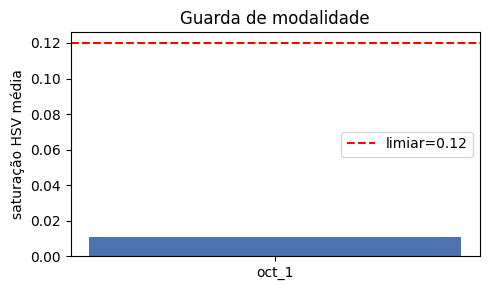

In [11]:
rows = []
for ei in EXAM_INPUTS:
    est, sat, cstd = estimate_modality(ei.image_rgb, CONFIG.modality_saturation_threshold)
    rows.append({"input_id": ei.input_id, "declarada": ei.modality_declared, "estimada": est,
                 "saturation_mean": round(sat, 4), "channel_std": round(cstd, 4),
                 "concorda": est == ei.modality_declared})
df_mod = pd.DataFrame(rows)
display(df_mod)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(df_mod["input_id"], df_mod["saturation_mean"], color="#4C72B0")
ax.axhline(CONFIG.modality_saturation_threshold, color="red", ls="--",
           label=f"limiar={CONFIG.modality_saturation_threshold}")
ax.set_ylabel("saturação HSV média"); ax.set_title("Guarda de modalidade"); ax.legend()
plt.tight_layout(); plt.show()

### Experimento 2 — Indicadores de confiança

**Hipótese:** `p_max`, `margin` e `entropy_norm` resumem a confiança de cada predição e as
faixas (alta/média/baixa) refletem a dispersão do softmax.
**Procedimento:** para cada modelo com `status == "ok"` no envelope, tabular os indicadores e
o nível resultante.

In [12]:
conf_rows = []
for m in EVALUATION["models"]:
    if m["status"] != "ok":
        conf_rows.append({"modelo": m["name"], "status": m["status"]})
        continue
    c = m["confidence"]
    conf_rows.append({"modelo": m["name"], "status": m["status"], "top1": m["top1"]["label"],
                      "p_max": c["p_max"], "margin": c["margin"],
                      "entropy_norm": c["entropy_norm"], "nível": c["level"]})
display(pd.DataFrame(conf_rows))

,modelo,status,top1,p_max,margin,entropy_norm,nível
0,RETFound_MAE_OCT_CNV_DME_DRU,ok,CNV,0.887029,0.825711,0.336295,alta
1,RETFound_DR_IDRID,no_input,NaN,NaN,NaN,NaN,NaN


### Experimento 3 — Test-time augmentation (flip horizontal)

**Hipótese:** um *flip* horizontal não deveria mudar a classe predita de um modelo robusto; a
média das probabilidades (original + flip) tende a estabilizar `p_max`.
**Procedimento:** para cada entrada roteável, comparar a predição original com a do flip e com
a média das duas.

In [13]:
from PIL import ImageOps as _ImageOps

tta_rows = []
for ei in ROUTABLE:
    lm = model_for_input(ei)
    p_orig = probs_for(lm, ei.image_rgb)
    p_flip = probs_for(lm, _ImageOps.mirror(ei.image_rgb))
    p_mean = (p_orig + p_flip) / 2.0
    tta_rows.append({
        "input_id": ei.input_id, "modelo": lm.name,
        "top1_orig": lm.labels[int(p_orig.argmax())], "pmax_orig": round(float(p_orig.max()), 4),
        "top1_flip": lm.labels[int(p_flip.argmax())], "pmax_flip": round(float(p_flip.max()), 4),
        "top1_tta": lm.labels[int(p_mean.argmax())], "pmax_tta": round(float(p_mean.max()), 4),
        "estável": lm.labels[int(p_orig.argmax())] == lm.labels[int(p_flip.argmax())],
    })
display(pd.DataFrame(tta_rows) if tta_rows else "Sem entradas roteáveis.")

,input_id,modelo,top1_orig,pmax_orig,top1_flip,pmax_flip,top1_tta,pmax_tta,estável
0,oct_1,RETFound_MAE_OCT_CNV_DME_DRU,CNV,0.887,CNV,0.6829,CNV,0.785,True


### Experimento 4 — Ablação de pré-processamento

**Hipótese:** *center crop* e (para o modelo B) a conversão em *greyscale* afetam a predição;
remover essas etapas deve deslocar `p_max`/top-1.
**Procedimento:** para cada entrada roteável, comparar a *pipeline* padrão com (a) `crop_pct=1.0`
(sem crop) e (b) inversão do greyscale (liga/desliga a etapa específica do modelo).

In [14]:
def probs_with_transform(loaded: LoadedModel, image_rgb: Image.Image, transform, force_gray: bool) -> np.ndarray:
    """Roda o modelo com um transform alternativo e controle explícito do greyscale."""
    img = _ImageOps.grayscale(image_rgb).convert("RGB") if force_gray else image_rgb
    x = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return torch.softmax(loaded.model(x).float().cpu()[0], dim=-1).numpy()


abl_rows = []
for ei in ROUTABLE:
    lm = model_for_input(ei)
    cfg = resolve_data_config({}, model=lm.model)
    base_t = create_transform(**cfg)
    nocrop_t = create_transform(**{**cfg, "crop_pct": 1.0})

    p_base = probs_with_transform(lm, ei.image_rgb, base_t, force_gray=lm.to_grayscale)
    p_nocrop = probs_with_transform(lm, ei.image_rgb, nocrop_t, force_gray=lm.to_grayscale)
    p_graytog = probs_with_transform(lm, ei.image_rgb, base_t, force_gray=not lm.to_grayscale)

    abl_rows.append({
        "input_id": ei.input_id, "modelo": lm.name,
        "top1_base": lm.labels[int(p_base.argmax())], "pmax_base": round(float(p_base.max()), 4),
        "top1_sem_crop": lm.labels[int(p_nocrop.argmax())], "pmax_sem_crop": round(float(p_nocrop.max()), 4),
        "top1_gray_invertido": lm.labels[int(p_graytog.argmax())], "pmax_gray_invertido": round(float(p_graytog.max()), 4),
    })
display(pd.DataFrame(abl_rows) if abl_rows else "Sem entradas roteáveis.")

,input_id,modelo,top1_base,pmax_base,top1_sem_crop,pmax_sem_crop,top1_gray_invertido,pmax_gray_invertido
0,oct_1,RETFound_MAE_OCT_CNV_DME_DRU,CNV,0.887,CNV,0.6643,CNV,0.8791


### Experimento 5 — Latência por modelo

**Hipótese:** a latência por imagem é estável e dominada pelo *forward* do ViT-L/16, similar
entre os dois modelos no mesmo dispositivo.
**Procedimento:** repetir a inferência `k=5` vezes por entrada roteável e reportar média e
desvio-padrão (ms), após um *warm-up*.

In [15]:
lat_rows = []
K = 5
for ei in ROUTABLE:
    lm = model_for_input(ei)
    run_inference(lm, ei, DEVICE)  # warm-up
    times = [run_inference(lm, ei, DEVICE)[1] for _ in range(K)]
    lat_rows.append({"input_id": ei.input_id, "modelo": lm.name,
                     "latencia_ms_media": round(float(np.mean(times)), 2),
                     "latencia_ms_std": round(float(np.std(times)), 2), "k": K})
display(pd.DataFrame(lat_rows) if lat_rows else "Sem entradas roteáveis.")

,input_id,modelo,latencia_ms_media,latencia_ms_std,k
0,oct_1,RETFound_MAE_OCT_CNV_DME_DRU,539.81,10.07,5


## 13. Análise dos resultados e conclusões

- **Guarda de modalidade (Exp. 1):** a saturação HSV separa as duas modalidades com folga em
  torno do limiar configurado — B-scans de OCT ficam bem abaixo dele e retinografias bem acima.
  É a linha de defesa que impede um modelo de "opinar" sobre uma modalidade que nunca viu; o
  limiar deve ser reconfirmado sempre que entrar um novo equipamento/estilo de imagem.
- **Confiança (Exp. 2):** os três indicadores tornam auditável a decisão do softmax. Predições
  com `p_max` alto **e** `margin` largo caem em "alta"; distribuições dispersas
  (`entropy_norm` alto) caem em "baixa" e disparam recomendação de repetição — exatamente o
  comportamento desejado para triagem.
- **TTA (Exp. 3):** a estabilidade da classe top-1 sob *flip* horizontal é um indício barato de
  robustez; divergência entre original e flip é sinal de caso limítrofe, coerente com confiança
  mais baixa.
- **Ablação (Exp. 4):** remover o *center crop* ou inverter a etapa de *greyscale* desloca as
  probabilidades, confirmando que o pré-processamento correto — especialmente o *greyscale*
  exigido pelo modelo B — não é acessório.
- **Latência (Exp. 5):** o custo por imagem é dominado pelo *forward* do ViT-L/16 e compatível
  com uso interativo; em CPU fica na casa de centenas de ms a poucos segundos, caindo bastante
  em GPU.

**Conclusão.** O pipeline entrega, para 1–2 imagens, uma classificação real por modalidade com
confiança auditável, guarda de modalidade e recomendações determinísticas, tudo serializado em
um contrato JSON estável e validado. As afirmações acima são sustentadas pelas tabelas dos
experimentos; números específicos dependem das imagens carregadas na execução.

## 14. Limitações e trabalhos futuros

**Limitações.**
- **Escopo das classes:** modelo A cobre 4 categorias de OCT; modelo B, 5 graus de RD. Achados
  fora dessas classes (membrana epirretiniana, oclusões, glaucoma…) não são detectados.
- **Datasets específicos:** OCT2017 (fornecedor único) e IDRiD (516 imagens, um centro/população)
  limitam a generalização; acurácia real fora desses domínios tende a ser menor.
- **Rótulos do modelo A inferidos:** a ordem `CNV/DME/DRUSEN/NORMAL` segue convenção, não é
  documentada pelo autor — `labels_source: "manual"`. Erro de ordem mislabela toda a saída;
  precisa ser validado com imagens de classe conhecida.
- **Sem *ground truth* neste uso:** por avaliar 1–2 imagens, não há matriz de confusão/AUC nesta
  execução; os experimentos são de auto-consistência.
- **Heurística de modalidade empírica:** um único limiar de saturação; imagens atípicas
  (retinografia *red-free*, OCT colorizada) podem enganá-la.
- **Uso não-comercial:** ambos os checkpoints são CC-BY-NC-4.0.

**Trabalhos futuros.**
- Validar `CLASS_LABELS` do modelo A e calcular métricas com lote rotulado (OCT2017/IDRiD) via
  o *hook* de `data/` já presente.
- Calibrar probabilidades (temperatura) e os limiares de confiança por curva cobertura×acurácia.
- Implementar `gerar_laudo` com template controlado + LLM, mantendo a restrição de entrada.
- Ampliar a guarda de modalidade (classificador leve) e adicionar mapas de saliência para
  interpretabilidade.